In [62]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split, Subset, Dataset
import torch.nn.functional as F
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import os
import hashlib
from PIL import Image
import numpy as np
import random
import copy

### Hardware and Project Configs

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# parallel processing fuer schnelleres trainieren des models
NUM_WORKERS = 0

# hyperparameters fuer lokales setup 
IMG_SIZE = 100 
NUM_CLASSES = 33

# batche size fuer dataloader
BATCH_SIZE = 64

# model hyperparameters
DROPOUT = 0.7
EPOCHS = 20
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4
PATIENCE_LIMIT = 5   

# pfade der bilder
TRAIN_DIR = "Fruits/train/train"   
TEST_DIR = "Fruits/test"

# seed fuer wiederholbarkeit
SEED = 42

print(f"configs fuer diesen run:\nworkers: {NUM_WORKERS}  | batch size: {BATCH_SIZE} | on device: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU'}")

configs fuer diesen run:
workers: 0  | batch size: 64 | on device: AMD Radeon RX 7700 XT


### Data Engineering

In [64]:
def clean_dataset(root_dir):
    hashes = {}                                     # dictionary um hashes zu speichern
    duplicates = []                                 # liste fuer gefundene duplikate
    corrupted = []                                  # liste fuer kaputte files

    print(f"Cleaning dataset in: {root_dir}...")

    for subdir, dirs, files in os.walk(root_dir):
        for file in files:
            filepath = os.path.join(subdir, file)
            
            try:
                # 1. Check for Corruption
                with Image.open(filepath) as img:
                    img.verify()                    # verify checkt ob file broken ist

                # 2. Check for Duplicates (MD5)
                # wir lesen das file im binary mode um den hash zu berechnen
                with open(filepath, 'rb') as f:
                    file_hash = hashlib.md5(f.read()).hexdigest()

                if file_hash in hashes:
                    duplicates.append(filepath)
                    print(f"Duplicate found: {filepath} == {hashes[file_hash]}")
                    os.remove(filepath)             # loesche das duplikat direkt
                else:
                    hashes[file_hash] = filepath    # speichere hash wenn neu
                
            except (IOError, SyntaxError) as e:
                print(f"Corrupted file found: {filepath}")
                corrupted.append(filepath)
                os.remove(filepath)                 # loesche kaputte files

    print(f"Cleanup Finished!")
    print(f"Removed Duplicates: {len(duplicates)}")
    print(f"Removed Corrupted:  {len(corrupted)}")
    print(f"Unique Images left: {len(hashes)}")

# Cleaning starten (nur fuer Train, Test data lassen wir meistens in ruhe)
clean_dataset(TRAIN_DIR)

Cleaning dataset in: Fruits/train/train...
Cleanup Finished!
Removed Duplicates: 0
Removed Corrupted:  0
Unique Images left: 16854


In [65]:
def get_class_setup(root_dir):
    # 1. Alle ordner auflisten
    # wir filtern sicherheitshalber hidden files (starten mit .) raus
    all_entries = os.listdir(root_dir)
    classes = [d for d in all_entries if os.path.isdir(os.path.join(root_dir, d))]
    
    # 2. Sortieren (WICHTIG: ImageFolder sortiert alphabetisch)
    classes.sort()
    
    # 3. Mapping erstellen (Name -> Nummer)
    class_to_idx = {cls_name: i for i, cls_name in enumerate(classes)}
    
    return classes, class_to_idx

# Globale variablen setzen
CLASS_NAMES, CLASS_TO_IDX = get_class_setup(TRAIN_DIR)
NUM_CLASSES = len(CLASS_NAMES)

print(f"Classes defined: {NUM_CLASSES}")
print(f"Sample: {CLASS_NAMES[:5]}")
print(f"Mapping: {list(CLASS_TO_IDX.items())[:5]}")

Classes defined: 33
Sample: ['Apple Braeburn', 'Apple Granny Smith', 'Apricot', 'Avocado', 'Banana']
Mapping: [('Apple Braeburn', 0), ('Apple Granny Smith', 1), ('Apricot', 2), ('Avocado', 3), ('Banana', 4)]


## EDA

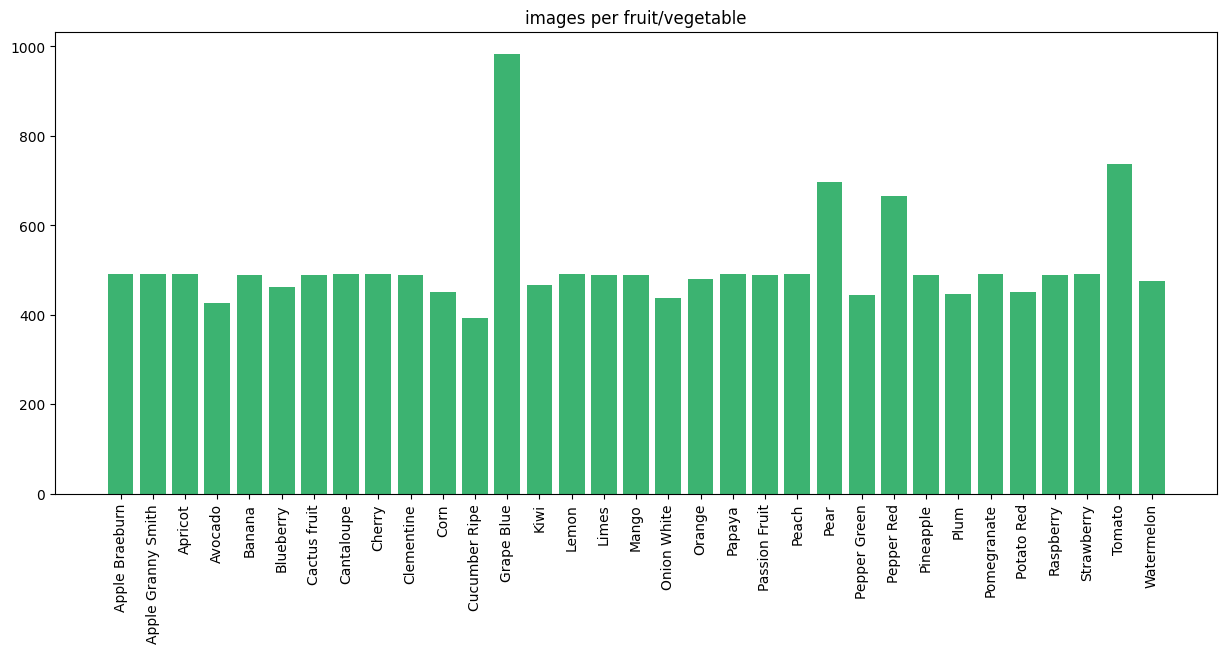

In [66]:
# diese listen speichern daten fuer die plots
fruit_names = []
fruit_counts = []


all_items = os.listdir(TRAIN_DIR)                   # extrahiere namen der folder

for item_name in all_items:                         # loop through every item found                      

    item_path = os.path.join(TRAIN_DIR, item_name)  # create the full path to the item
    

    if os.path.isdir(item_path):                    # erst checken ob es sich um ein directory handelt
        files_inside = os.listdir(item_path)        # alle files auflisten
        number_of_images = len(files_inside)        # count how many files are in there
        
        fruit_names.append(item_name)               # append namen in die liste
        fruit_counts.append(number_of_images)       # append count in die liste


plt.figure(figsize=(15, 6))                         # erstellt die figure fuer den plot mit (width=15, height=6)
plt.bar(fruit_names, fruit_counts, color='mediumseagreen') 
plt.title("images per fruit/vegetable")                      
plt.xticks(rotation=90)                             
plt.show()

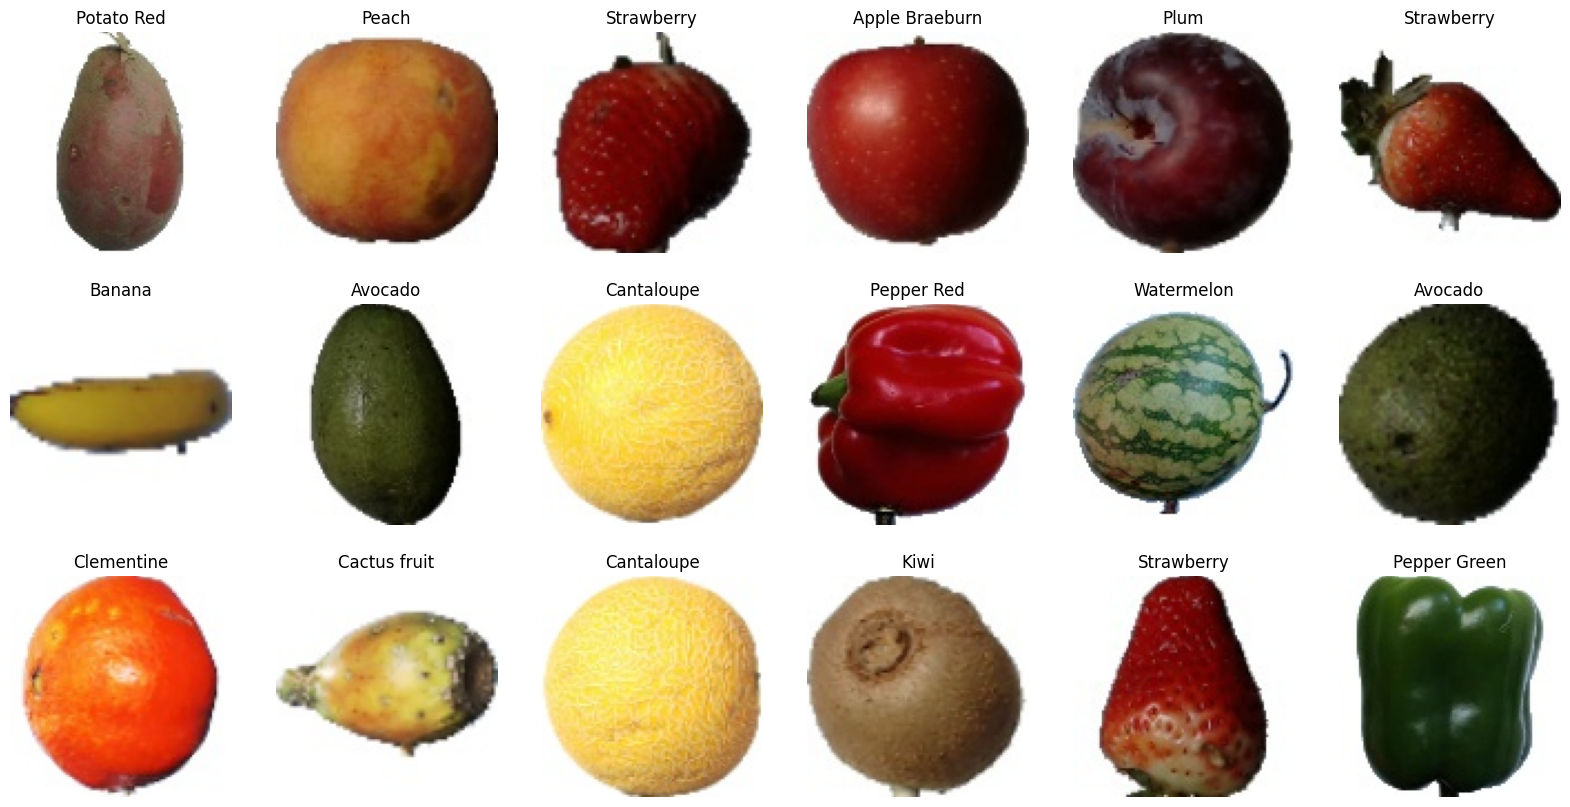

In [67]:
plt.figure(figsize=(20, 10))                        # create a new figure for the images
for i in range(18):
    random_fruit = random.choice(fruit_names)       # pick a random fruit name from our list
    fruit_folder = os.path.join(TRAIN_DIR, random_fruit)
    files_in_fruit_folder = os.listdir(fruit_folder)
    random_file = random.choice(files_in_fruit_folder)
    image_location = os.path.join(fruit_folder, random_file)
    
    img = Image.open(image_location)
    
   
    plt.subplot(3, 6, i + 1)                        # sublot fuer ein 3x6 feld
                                                    # i + 1 weil matplotlib erst mit 1 beginnt, nicht mit 0 (wegen der range() function)
    plt.imshow(img)
    plt.title(random_fruit)
    plt.axis('off')


plt.show()

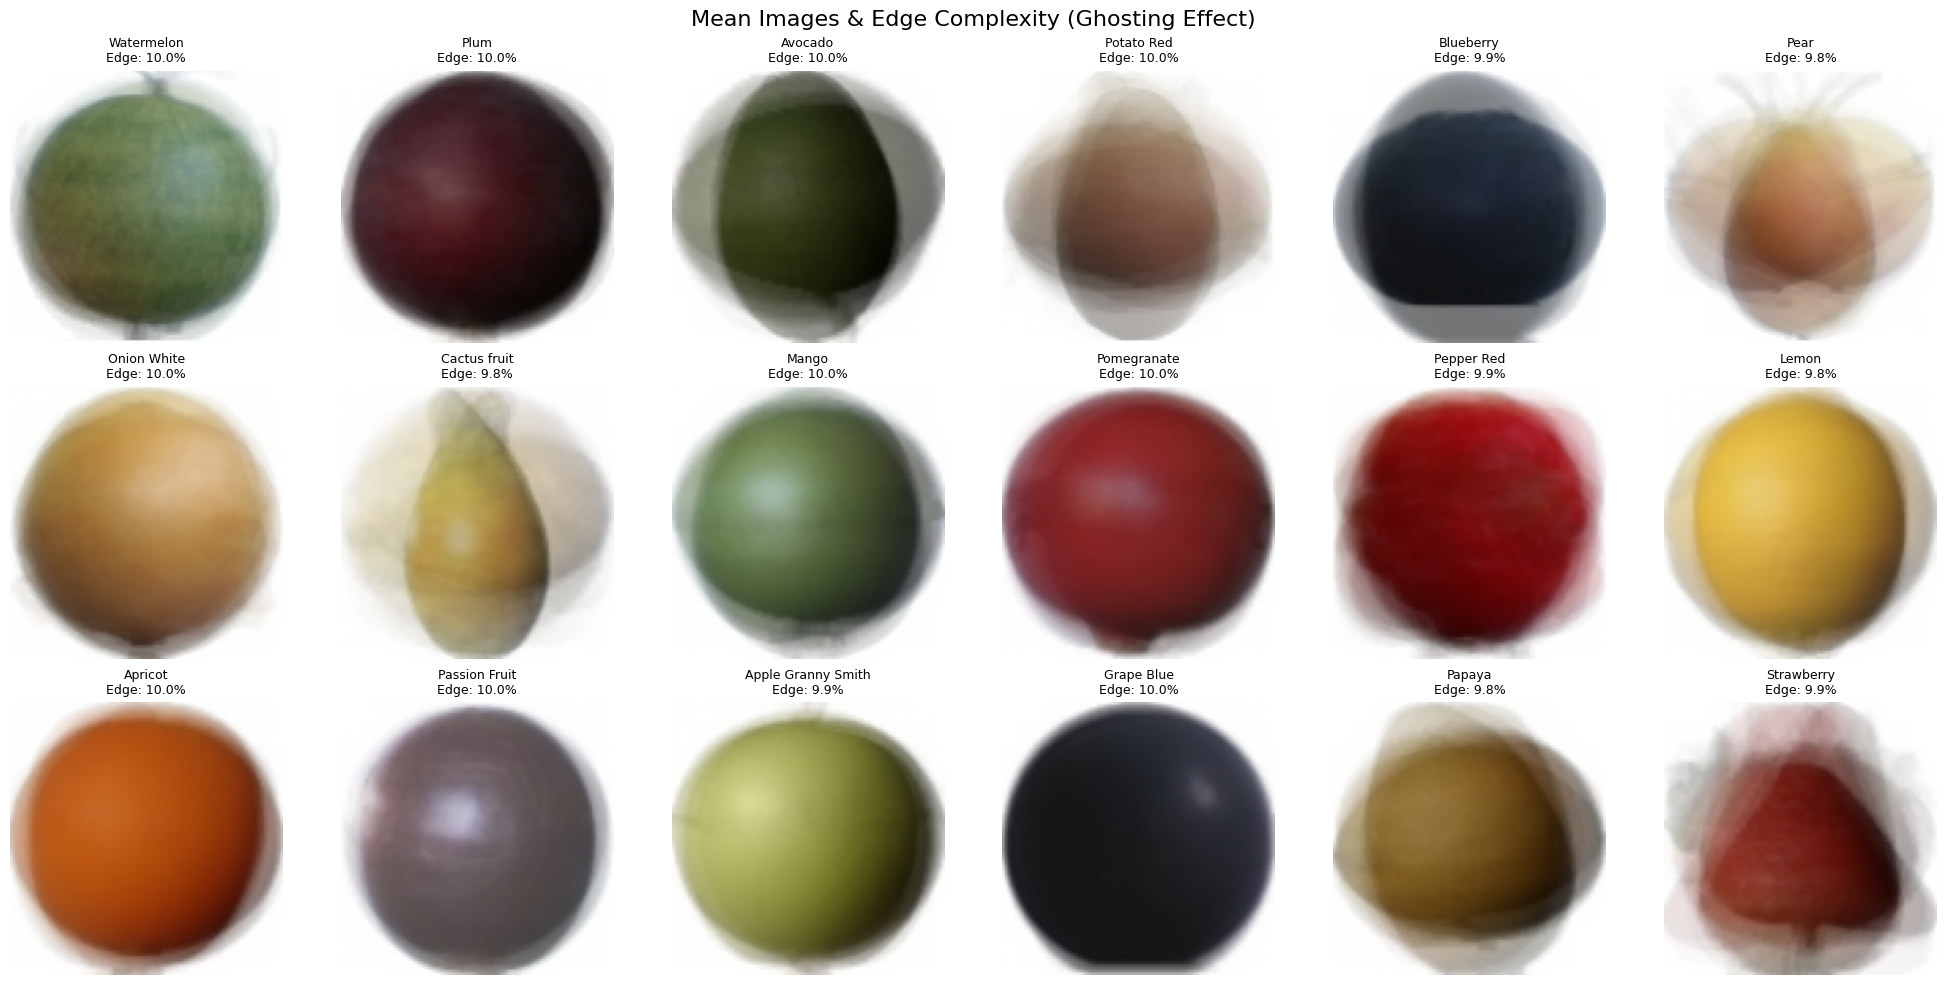

In [68]:
import numpy as np

# wir waehlen 18 zufaellige klassen (fruechte) aus
unique_fruits = os.listdir(TRAIN_DIR)
selected_fruits = random.sample(unique_fruits, 18)  # pick 18 random fruits

plt.figure(figsize=(20, 10))                        # create a new figure for the images
plt.suptitle("Mean Images & Edge Complexity (Ghosting Effect)", fontsize=16)

for i, fruit_name in enumerate(selected_fruits):
    
    fruit_folder = os.path.join(TRAIN_DIR, fruit_name)
    all_files = os.listdir(fruit_folder)
    
    # performance schutz: wir nehmen maximal 50 bilder fuer den mittelwert
    # sonst laeuft der arbeitsspeicher voll bei grossen datasets
    sample_size = min(len(all_files), 50)
    sampled_files = random.sample(all_files, sample_size)
    
    images_bucket = []
    
    for file in sampled_files:
        img_path = os.path.join(fruit_folder, file)
        try:
            # bild laden und direkt in array umwandeln
            img = Image.open(img_path).convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE))  # sicherstellen dass alle gleich gross sind
            images_bucket.append(np.array(img, dtype=np.float32))
        except:
            continue
            
    if not images_bucket:
        continue

    # 1. Mittelwertbild berechnen (Classmate's Logic)
    # axis=0 bedeutet wir mitteln "durch" den stapel an bildern
    mean_image = np.mean(images_bucket, axis=0).astype(np.uint8)
    
    # 2. Gradient / Edge Berechnung (Classmate's Logic)
    mean_gray = np.mean(mean_image, axis=2)         # helligkeit extrahieren
    
    # gradienten berechnen (kanten finden)
    grad_x = np.abs(np.diff(mean_gray, axis=1, append=mean_gray[:, -1:]))
    grad_y = np.abs(np.diff(mean_gray, axis=0, append=mean_gray[-1:, :]))
    gradient = grad_x + grad_y
    
    # prozentualen anteil berechnen
    threshold = np.percentile(gradient, 90)         # nur die stärksten 10% kanten zaehlen
    edge_mask = gradient > threshold
    percent_edge = 100 * edge_mask.sum() / edge_mask.size

    # 3. Plotting (Your Grid Logic)
    plt.subplot(3, 6, i + 1)                        # subplot positionierung
    plt.imshow(mean_image)
    
    # titel zeigt namen UND die komplexitaet
    plt.title(f"{fruit_name}\nEdge: {percent_edge:.1f}%", fontsize=9)
    plt.axis('off')

plt.tight_layout()
plt.show()

### Data Transformation

In [69]:
# transformations fuer das training (mit augmentation)
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),     # alle bilder auf gleiche groesse bringen
    transforms.RandomRotation(20),               # Dreht das Bild zufällig um +/-20°
    transforms.RandomHorizontalFlip(),           # Spiegelt das Bild zufällig horizontal
    transforms.RandomAffine(                     # Zufällige Verschiebung in x- und y-Richtung, Zoom in oder out, Rotation bereits oben festgelegt
        degrees=0,
        translate=(0.1, 0.1),
        scale=(0.9, 1.1)
    ),
    # --- PHOTOMETRIC (New - Crucial for "wild" data) ---
    transforms.ColorJitter(
        brightness=0.2,  # Simulate shadows/bright light
        contrast=0.2,    # Simulate different cameras
        saturation=0.2,  # Simulate different ripeness
        hue=0.05         # Slight color shift
    ),
    transforms.RandomGrayscale(p=0.1), # Forces model to look at shape, not just color
    transforms.GaussianBlur(kernel_size=3),

    #Wandelt Bilder in einen Tensor (mehrdimensionale Matrix) um und normalisiert diese auf -1 bis 1 für Stabileres Training
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])
#Keine Augmentation für Testbilder
test_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5],
                         std=[0.5, 0.5, 0.5])
])

### Data Split

In [70]:
# 1. Define the split sizes first
total_len = len(datasets.ImageFolder(root=TRAIN_DIR))
train_size = int(0.8 * total_len)
val_size = total_len - train_size

# 2. Generate consistent indices for the split
# Fix the generator seed so the split is always the same
generator = torch.Generator().manual_seed(123)
train_dataset, val_dataset = random_split(range(total_len), [train_size, val_size], generator=generator)

# Get the indices from the random split
train_indices = train_dataset.indices
val_indices = val_dataset.indices

# 3. Create two separate datasets
# One with augmentation
train_data_source = datasets.ImageFolder(root=TRAIN_DIR, transform=train_transform)
# One without augmentation (clean)
val_data_source = datasets.ImageFolder(root=TRAIN_DIR, transform=test_transform)

# 4. Create the final Subsets using the indices
train_dataset = Subset(train_data_source, train_indices)
val_dataset = Subset(val_data_source, val_indices)

# Now train_dataset uses train_transform, and val_dataset uses test_transform

test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transform
)

### Loaders

In [71]:
#Bereitstellung der Daten für das Modell, nimmt hyperparameter batch size, bei Training shuffeln wir die Bilder damit keine Reihenfolgemuster gelernt werden
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE, 
    shuffle=True,
    pin_memory=True)
val_loader = DataLoader(
    val_dataset, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    pin_memory=True)
test_loader = DataLoader(
    test_dataset,
    batch_size=20,  # 20 Bilder für die Visualisierung
    shuffle=True,
    pin_memory=True)

print("Train samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))

Train samples: 13483
Validation samples: 3371


### Building the Model

##Feature Extraction:
**Conv2d:**

*   in_channels=3 -> RGB Bild
*   out_channels=32 -> 32 Filter die unterschiedliche Muster erkennen (z. B. Kanten, Farben, Texturen)
*   kernel_size=3 -> Größe der Filter = 3×3 Pixel

Erstellung von Feature Maps
<br>
<br>
**ReLU:**<br>
Aktivierungsfunktion -> fügt Nichtlinearität hinzu, ohne ReLU könnte das CNN nur lineare Muster lernen
<br>
<br>
**MaxPool2d:**<br>
Reduziert räumliche Größe der Feature-Maps um Faktor 2, weniger Paramter und robust gegen kleine Verschiebungen im Bild
<br>
<br>
<br>
Anschließend 64 Filter und dann 128 Filter mit gleicher Logik (channel in immer der Wert des channel out vom vorherigen Block)<br>
Mit jedem Block werden komplexere und abstraktere Merkmale erlernt
<br>
<br>
## Classification head

**Flatten:**

Wandelt die 3D-Feature-Maps in einen Vektor um -> nötig für Dense Layer
(Convolutional Layer arbeitet räumlich (2D), Dense Layer nicht)
<br>
<br>
**Linear:**<br>
Kombiniert alle gelernten Merkmale, lernt welche Feature-Kombinationen typisch für welche Klasse sind (Input: 18.432 gelernte Features, Output: 256 Neuronen)
<br>
-> ein Dense Layer (Fully Connected Layer), jedes der 256 Neuronen (ein Neuron lernt eine bestimmte Kombination von Merkmalen, z.B. langgestreckt + gelb + gebogen) ist mit allen Eingabewerten verbunden (alle gelernten Features)
<br>
<br>
**ReLU:**<br>
Dense Layer arbeitet anders als Convolutional Layer (global, keine räumliche Struktur, Gewichtsmatrix (wie wichtig ist ein Feature für ein Neuron))
<br>
<br>
**Dropout:**<br>
während Training werden 50 % der Neuronen zufällig deaktiviert (es kann sich nicht auf einzelne Neuronen verlassen)
<br>
<br>
**Linear:**<br>
Finale output Layer, 256 Features (ein Feature pro Neuron) werden in 33 Werte umgewandelt, wobei jeder Wert einer Fruchtklasse entspricht

In [ ]:
model = nn.Sequential(
    
    # Block 1: Input -> 32 Filters
    nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),            # 100x100 -> 50x50

    # Block 2: 32 -> 64 Filters
    nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),            # 50x50 -> 25x25

    # Block 3: 64 -> 128 Filters
    nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),            # 25x25 -> 12x12

    nn.Conv2d(in_channels=128, out_channels=256, kernel_size=3, padding=1),
    nn.ReLU(),
    nn.MaxPool2d(kernel_size=2),            # 12x12 -> 6x6

    
    nn.Flatten(),                           # 3D Tensor -> 1D Vector
    nn.Linear(128 * 12 * 12, 256),          # Hidden Layer mit 256 Neuronen
    nn.ReLU(),
    nn.Dropout(DROPOUT),                    #  Wahrscheinlichkeit Neuronen zu deaktivieren
    nn.Linear(256, NUM_CLASSES)             # Output Layer (Anzahl der Fruechte)
    
).to(DEVICE)                                # Modell auf die GPU/CPU schieben



**Loss-Funktion**

Was es macht:
Vergleicht die vom Modell vorhergesagten Logits (Ausgabewerte des letzten Layers, noch keine Wahrscheinlichkeiten) mit den echten Labels.
→ Berechnet, wie „falsch“ das Modell liegt.

Warum CrossEntropyLoss:

Für Multi-Klassen-Klassifikation geeignet (hier: 33 Fruchtklassen).

Intern wendet CrossEntropy Softmax auf die Logits an, um Wahrscheinlichkeiten zu erzeugen.

Misst, wie gut die Wahrscheinlichkeitsverteilung der Vorhersage zu den tatsächlichen Labels passt.

Merksatz:
„Loss sagt dem Modell, wie sehr es daneben liegt, damit die Gewichte beim Backpropagation angepasst werden können.“
<br>
<br>
**Optimizer**

Was es macht:
Aktualisiert die Gewichte des Modells, um den Loss zu minimieren.
→ Führt das „Lernen“ durch Gradientenschritte aus.

Warum Adam:

Beliebter Optimizer für CNNs.

Kombiniert Momentum + adaptive Lernraten pro Parameter.

Meist schneller und stabiler als normales SGD.

Parameter:

model.parameters() → Alle Gewichte im Modell werden trainiert.

lr=1e-3 → Lernrate: Schrittgröße bei jedem Update.

Merksatz:
„Der Optimizer entscheidet, wie die Gewichte angepasst werden, um den Loss zu minimieren.“

### Training Setup

In [ ]:
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# TRAINING SETUP

train_losses = []
val_losses = []
train_accs = []
val_accs = []

# early stopping configs
                                                    # wie viele epochen warten wir ohne verbesserung?
patience_counter = 0                                # zaehler fuer schlechte epochen
best_val_loss = float('inf')                        # startwert fuer vergleich

### Training Loop

In [74]:
for epoch in range(1, EPOCHS + 1):
    
    #1. lernen (training) 
    model.train()                                   # lernmodus an
    running_train_loss = 0.0
    correct_train, total_train = 0, 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)           # daten auf die grafikkarte schieben
        optimizer.zero_grad()                       # gedächtnis löschen (alte fehler von vorhin vergessen)
        logits = model(x)                           # raten
        loss = loss_fn(logits, y)                   # fehler berechnen
        
        loss.backward()                             # lernen
        optimizer.step()                            # verbessern
        running_train_loss += loss.item()           # fehler merken für die statistik zusammenrechnen
        pred = logits.argmax(dim=1)                 # die antwort mit der höchsten punktzahl wählen
        correct_train += (pred == y).sum().item()   # count wie oft es richtig lag
        total_train += y.size(0)                    # insgesamt verarbeitete bilder zählen
    avg_train_loss = running_train_loss / len(train_loader) # durchschnitts-fehler beim lernen
    train_acc = correct_train / total_train                 # trefferquote (0.0 bis 1.0)
    
    # 2. pruefen (validierung)
    model.eval()                                      # lernen deaktivieren 
    running_val_loss = 0.0
    correct_val, total_val = 0, 0
    with torch.no_grad():                           
        for x, y in val_loader:
            x, y = x.to(DEVICE), y.to(DEVICE)
            logits = model(x)                         # raten
            loss = loss_fn(logits, y)                 # fehler bei der prüfung berechnen
            running_val_loss += loss.item()           # fehler zusammenrechnen
            pred = logits.argmax(dim=1)               # die antwort mit der höchsten punktzahl wählen
            correct_val += (pred == y).sum().item()   # count wie oft es richtig lag
            total_val += y.size(0)                    # insgesamt verarbeitete bilder zählen
    avg_val_loss = running_val_loss / len(val_loader) # durchschnitts-fehler bei der validierung
    val_acc = correct_val / total_val                 # trefferquote bei der validierung
    
    # metriken speichern für die plots
    train_losses.append(avg_train_loss)
    val_losses.append(avg_val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)
    
    # 3. early stopping
    # verhindert overfitting der epochen
    
    if avg_val_loss < best_val_loss:                
        # fall a: das modell ist besser geworden
        best_val_loss = avg_val_loss
        patience_counter = 0                        # zähler zurücksetzen
        torch.save(model.state_dict(), "best_fruit_model.pth") # das "beste wissen" speichern               
    else:
        # fall b: es wird nicht mehr besser.
        patience_counter += 1                       # einen "strafpunkt" geben
    
    # fortschritt anzeigen
    print(f"runde {epoch:02d} | "
          f"fehler training: {avg_train_loss:.4f} | "
          f"fehler prüfung: {avg_val_loss:.4f} | "
          f"genauigkeit: {val_acc:.4f}")
    
    # schauen, ob wir abbrechen müssen
    if patience_counter >= PATIENCE_LIMIT:
        model.load_state_dict(torch.load("best_fruit_model.pth")) # das beste modell wieder laden
        break

print("fertig!")

runde 01 | fehler training: 2.7608 | fehler prüfung: 1.4431 | genauigkeit: 0.6651
runde 02 | fehler training: 1.9529 | fehler prüfung: 0.7986 | genauigkeit: 0.8698
runde 03 | fehler training: 1.5895 | fehler prüfung: 0.5863 | genauigkeit: 0.8754
runde 04 | fehler training: 1.3479 | fehler prüfung: 0.4134 | genauigkeit: 0.9214
runde 05 | fehler training: 1.2118 | fehler prüfung: 0.3371 | genauigkeit: 0.9244
runde 06 | fehler training: 1.0998 | fehler prüfung: 0.3035 | genauigkeit: 0.9338
runde 07 | fehler training: 1.0081 | fehler prüfung: 0.2386 | genauigkeit: 0.9413
runde 08 | fehler training: 0.9264 | fehler prüfung: 0.2104 | genauigkeit: 0.9537
runde 09 | fehler training: 0.8895 | fehler prüfung: 0.1945 | genauigkeit: 0.9490
runde 10 | fehler training: 0.8237 | fehler prüfung: 0.1814 | genauigkeit: 0.9505
runde 11 | fehler training: 0.7813 | fehler prüfung: 0.1563 | genauigkeit: 0.9555
runde 12 | fehler training: 0.7569 | fehler prüfung: 0.1560 | genauigkeit: 0.9531
runde 13 | fehle

### Error Loss und Validierung Loss

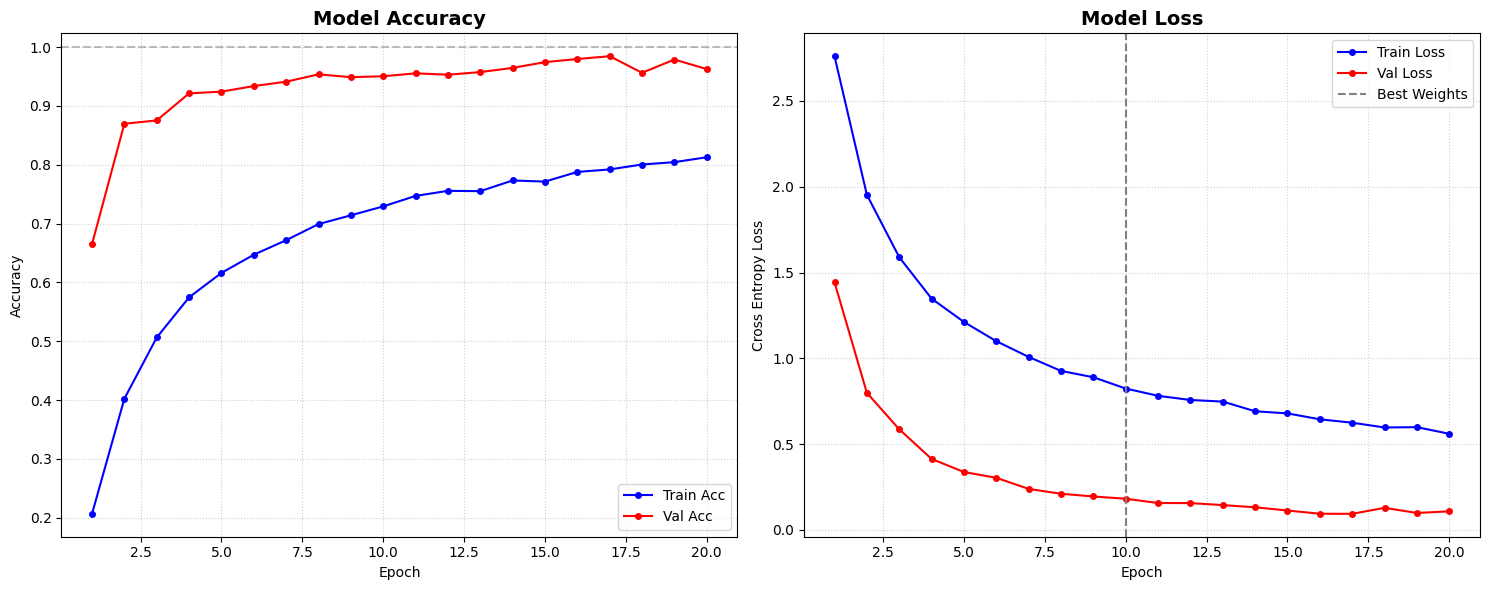

In [75]:
plt.figure(figsize=(15, 6))

# Sicherstellen, dass die Achsen übereinstimmen (wegen Early Stopping)
num_epochs = min(len(train_losses), len(val_losses))
epochs = range(1, num_epochs + 1)

# --- Subplot 1: ACCURACY ---
plt.subplot(1, 2, 1)
plt.plot(epochs, train_accs[:num_epochs], 'b-o', label="Train Acc", markersize=4)
plt.plot(epochs, val_accs[:num_epochs], 'r-o', label="Val Acc", markersize=4)
plt.axhline(y=1.0, color='gray', linestyle='--', alpha=0.5) # 100% Markierung
plt.title("Model Accuracy", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

# --- Subplot 2: LOSS ---
plt.subplot(1, 2, 2)
plt.plot(epochs, train_losses[:num_epochs], 'b-o', label="Train Loss", markersize=4)
plt.plot(epochs, val_losses[:num_epochs], 'r-o', label="Val Loss", markersize=4)
if num_epochs >= 10:
    plt.axvline(x=10, color='gray', linestyle='--', label='Best Weights')
plt.title("Model Loss", fontsize=14, fontweight='bold')
plt.xlabel("Epoch")
plt.ylabel("Cross Entropy Loss")
plt.legend()
plt.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

### Predictions

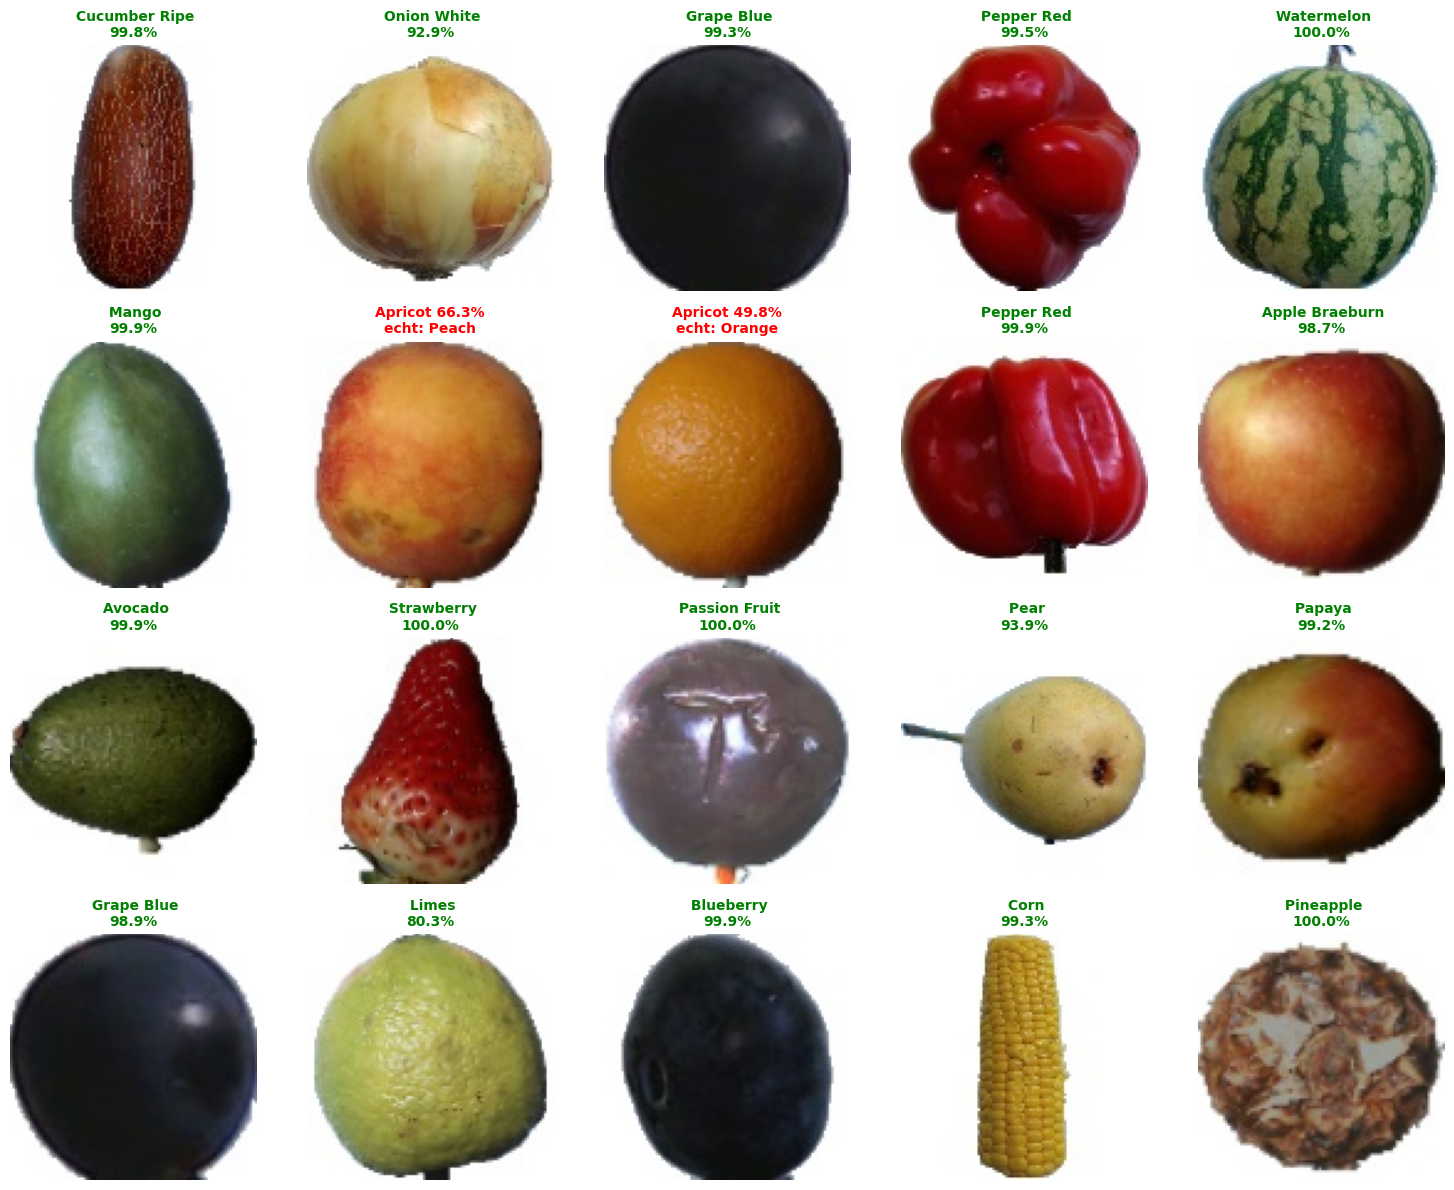

In [ ]:
# 1. einen stapel bilder und die echten labels laden
dataiter = iter(val_loader)
images, labels = next(dataiter)
images = images.to(DEVICE)
labels = labels.to(DEVICE)

# 2. das modell nach seiner meinung fragen
model.eval()
with torch.no_grad():
    outputs = model(images)
    probs = F.softmax(outputs, dim=1)              # in wahrscheinlichkeit umwandeln
    confidences, predictions = torch.max(probs, 1) # das beste ergebnis nehmen

# 3. die anzeige vorbereiten (4 reihen, 5 spalten)
plt.figure(figsize=(15, 12))
for i in range(20):
    if i >= len(images): break
    
    # platz für das nächste bild im gitter
    plt.subplot(4, 5, i + 1)
    
    # bild für uns sichtbar machen
    img = images[i].cpu().numpy().transpose((1, 2, 0))
    img = img * 0.5 + 0.5                          # farben korrigieren
    img = np.clip(img, 0, 1)                       # fehler in den farben verhindern
    
    plt.imshow(img)    
    # daten für den text holen
    true_label = CLASS_NAMES[labels[i]]
    pred_label = CLASS_NAMES[predictions[i]]
    conf_val = confidences[i].item() * 100
    
    # farbe: grün wenn richtig, rot wenn falsch
    farbe = 'green' if true_label == pred_label else 'red'
    
    # text ohne klammern zusammenbauen
    if true_label == pred_label:
        titel = f" {pred_label}\n{conf_val:.1f}%"
    else:
        titel = f"{pred_label} {conf_val:.1f}%\necht: {true_label}"
    
    plt.title(titel, color=farbe, fontsize=10, fontweight='bold')
    plt.axis('off')                              

plt.tight_layout()
plt.show()

Teste Modell auf 5641 Bildern aus ./downloads...
📦 Suche nach Bildern, die das Modell als 'Apple Braeburn' klassifiziert...
✅ 10 Bilder gefunden.


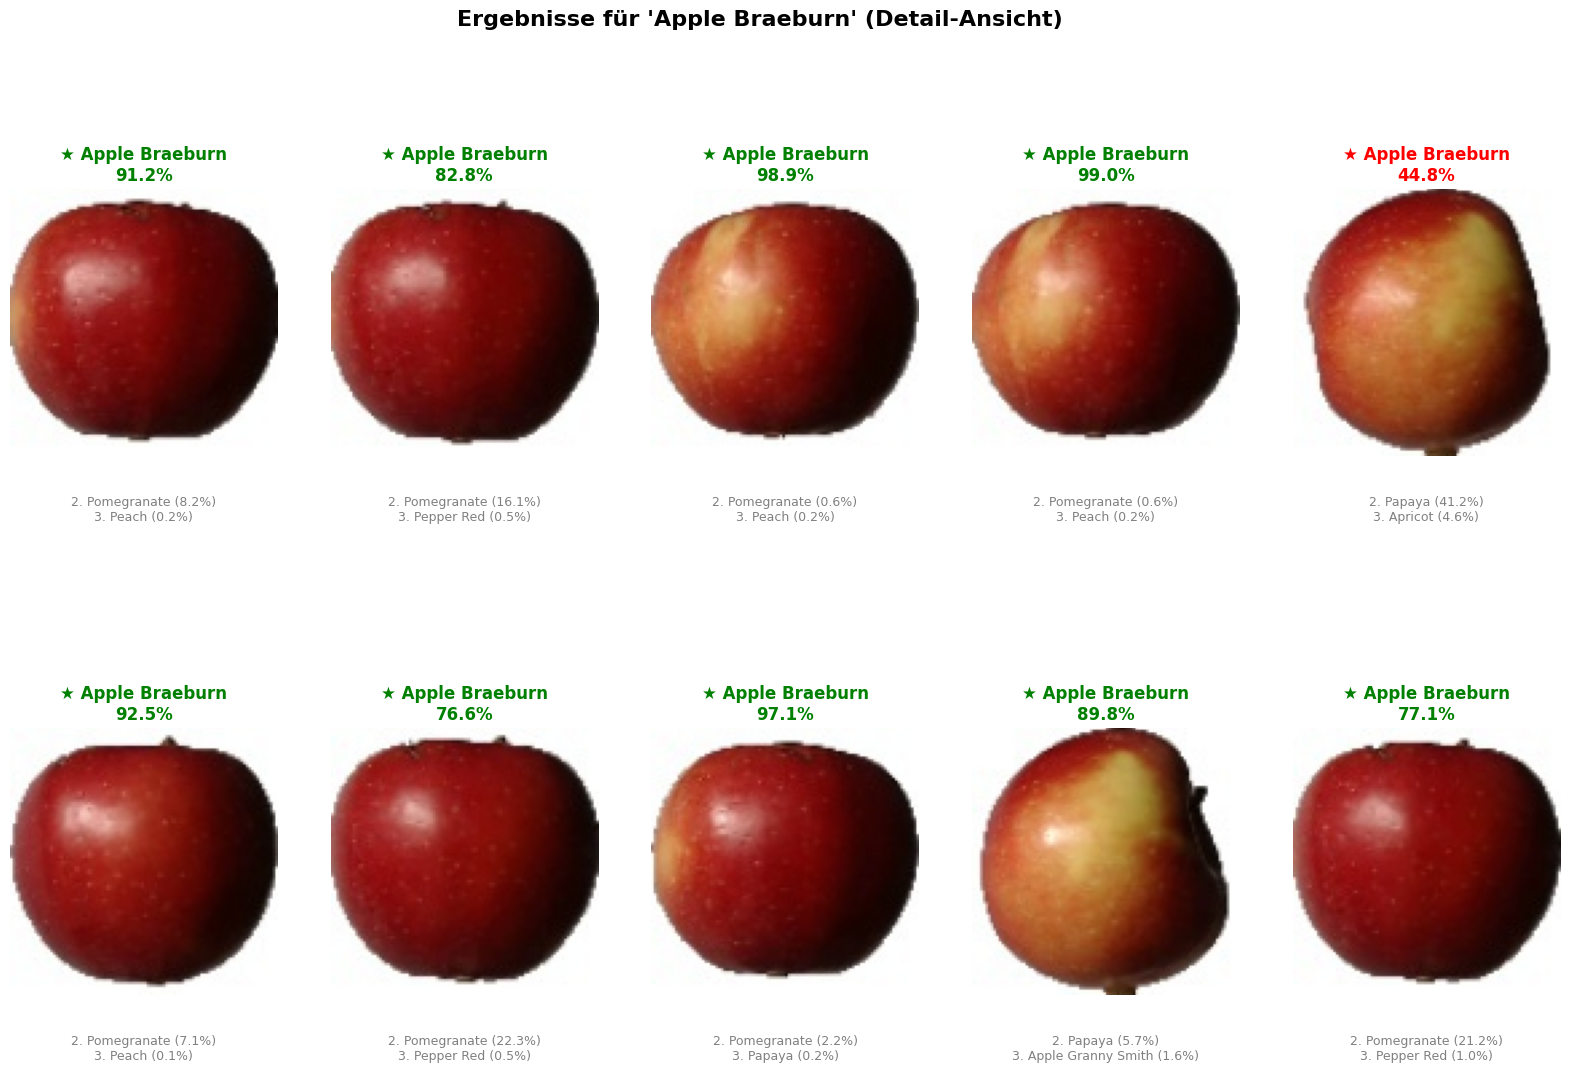

In [115]:
# Test auf echten Test-Daten aus dem Test-Ordner
print(f"Teste Modell auf {len(test_dataset)} Bildern aus {TEST_DIR}...")

# 1. Eine zufällige Fruchtklasse aus dem Modell auswählen
random_class_idx = random.randint(0, len(CLASS_NAMES) - 1)
random_class_name = CLASS_NAMES[random_class_idx]
print(f"📦 Suche nach Bildern, die das Modell als '{random_class_name}' klassifiziert...")

# 2. Durch alle Test-Bilder gehen
model.eval()
predicted_as_class = []

with torch.no_grad():
    for idx in range(len(test_dataset)):
        image, _ = test_dataset[idx]
        image = image.unsqueeze(0).to(DEVICE)
        
        outputs = model(image)
        prediction = outputs.argmax(dim=1).item()
        
        if prediction == random_class_idx:
            predicted_as_class.append(idx)
        
        if len(predicted_as_class) >= 10:
            break

# 3. Prüfen und Anzeigen
if len(predicted_as_class) == 0:
    print(f"❌ Keine Bilder gefunden für {random_class_name}!")
else:
    num_images = len(predicted_as_class)
    print(f"✅ {num_images} Bilder gefunden.")
    
    # Gitter höher machen, damit der Text drunter passt
    plt.figure(figsize=(20, 12))
    
    for plot_idx, img_idx in enumerate(predicted_as_class):
        # Bild laden
        image, _ = test_dataset[img_idx]
        image_input = image.unsqueeze(0).to(DEVICE)
        
        # Vorhersage (Top 3)
        with torch.no_grad():
            outputs = model(image_input)
            probs = F.softmax(outputs, dim=1)
            top3_probs, top3_idxs = torch.topk(probs, 3, dim=1)
        
        # --- FARB-LOGIK (Nur für Platz 1) ---
        top1_prob = top3_probs[0][0].item() * 100
        top1_name = CLASS_NAMES[top3_idxs[0][0].item()]
        
        if top1_prob < 50:
            color_top = 'red'
        elif top1_prob < 75:
            color_top = 'darkorange'
        else:
            color_top = 'green'
            
        # --- TEXT AUFTEILUNG ---
        # 1. Der Gewinner (Groß für den Titel)
        title_main = f"★ {top1_name}\n{top1_prob:.1f}%"
        
        # 2. Die Verfolger (Klein für den Untertitel)
        runners_up = []
        for k in range(1, 3): # Start bei Index 1 (Platz 2)
            k_name = CLASS_NAMES[top3_idxs[0][k].item()]
            k_prob = top3_probs[0][k].item() * 100
            runners_up.append(f"{k+1}. {k_name} ({k_prob:.1f}%)")
        
        subtitle = "\n".join(runners_up)

        # Bild anzeigen
        img = image.cpu().numpy().transpose((1, 2, 0))
        img = img * 0.5 + 0.5
        img = np.clip(img, 0, 1)
        
        ax = plt.subplot(2, 5, plot_idx + 1)
        plt.imshow(img)
        
        # Titel: Groß und Farbig
        plt.title(title_main, color=color_top, fontsize=12, fontweight='bold')
        
        # Untertitel: Klein und Grau (manuell platziert)
        # y=-0.1 setzt den Text unter das Bild
        plt.text(0.5, -0.15, subtitle, 
                 transform=ax.transAxes, 
                 ha='center', va='top', 
                 fontsize=9, color='gray')
        
        plt.axis('off')
    
    plt.suptitle(f"Ergebnisse für '{random_class_name}' (Detail-Ansicht)", 
                 fontsize=16, fontweight='bold', y=0.98)
    
    # Mehr Platz zwischen den Bildern lassen für den Text
    plt.subplots_adjust(hspace=0.4, wspace=0.2)
    plt.show()

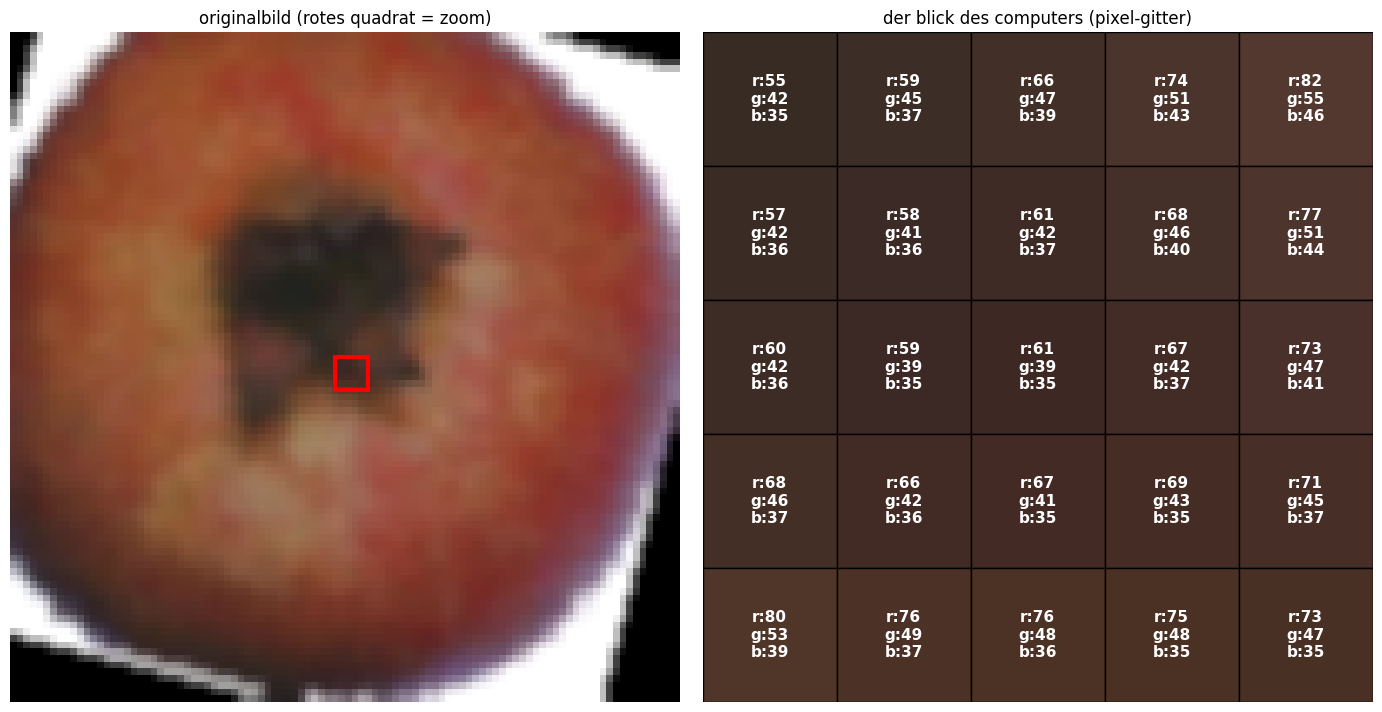

In [78]:
# 1. ein zufälliges bild aus dem dataset wählen
sample_idx = random.randint(0, len(train_dataset) - 1)
sample_img, _ = train_dataset[sample_idx]
img_orig = sample_img.cpu().numpy().transpose((1, 2, 0))
img_orig = np.clip(img_orig * 0.5 + 0.5, 0, 1)

# 2. einen winzigen ausschnitt (5x5 pixel) aus der mitte nehmen
# wir vergrößern diesen bereich extrem
x_start, y_start = 48, 48
patch = img_orig[y_start:y_start+5, x_start:x_start+5]

# 3. anzeige erstellen
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 7))

# linke seite: das originalbild mit markierung, wo wir "reinzoomen"
ax1.imshow(img_orig)
ax1.add_patch(plt.Rectangle((x_start, y_start), 5, 5, color='red', fill=False, linewidth=3))
ax1.set_title("originalbild (rotes quadrat = zoom)")
ax1.axis('off')

# rechte seite: das pixel-gitter (alle boxen verbunden)
ax2.set_title("der blick des computers (pixel-gitter)")
for y in range(5):
    for x in range(5):
        farbe_rgb = patch[y, x]
        # werte von 0.0-1.0 auf 0-255 umrechnen
        r, g, b = (farbe_rgb * 255).astype(int)
        
        # ein quadrat zeichnen (keine lücken durch xy-positionen)
        rect = plt.Rectangle((x, 4-y), 1, 1, facecolor=farbe_rgb, edgecolor='black')
        ax2.add_patch(rect)
        
        # die zahlen direkt in das quadrat schreiben
        # farbe des textes anpassen: weißer text auf dunklen pixeln, schwarzer auf hellen
        text_farbe = 'white' if np.mean(farbe_rgb) < 0.5 else 'black'
        ax2.text(x + 0.5, 4 - y + 0.5, f"r:{r}\ng:{g}\nb:{b}", 
                 ha='center', va='center', color=text_farbe, fontsize=11, fontweight='bold')

# koordinaten einstellen, damit man nur die 5x5 boxen sieht
ax2.set_xlim(0, 5)
ax2.set_ylim(0, 5)
ax2.set_aspect('equal')
ax2.axis('off')

plt.tight_layout()
plt.show()

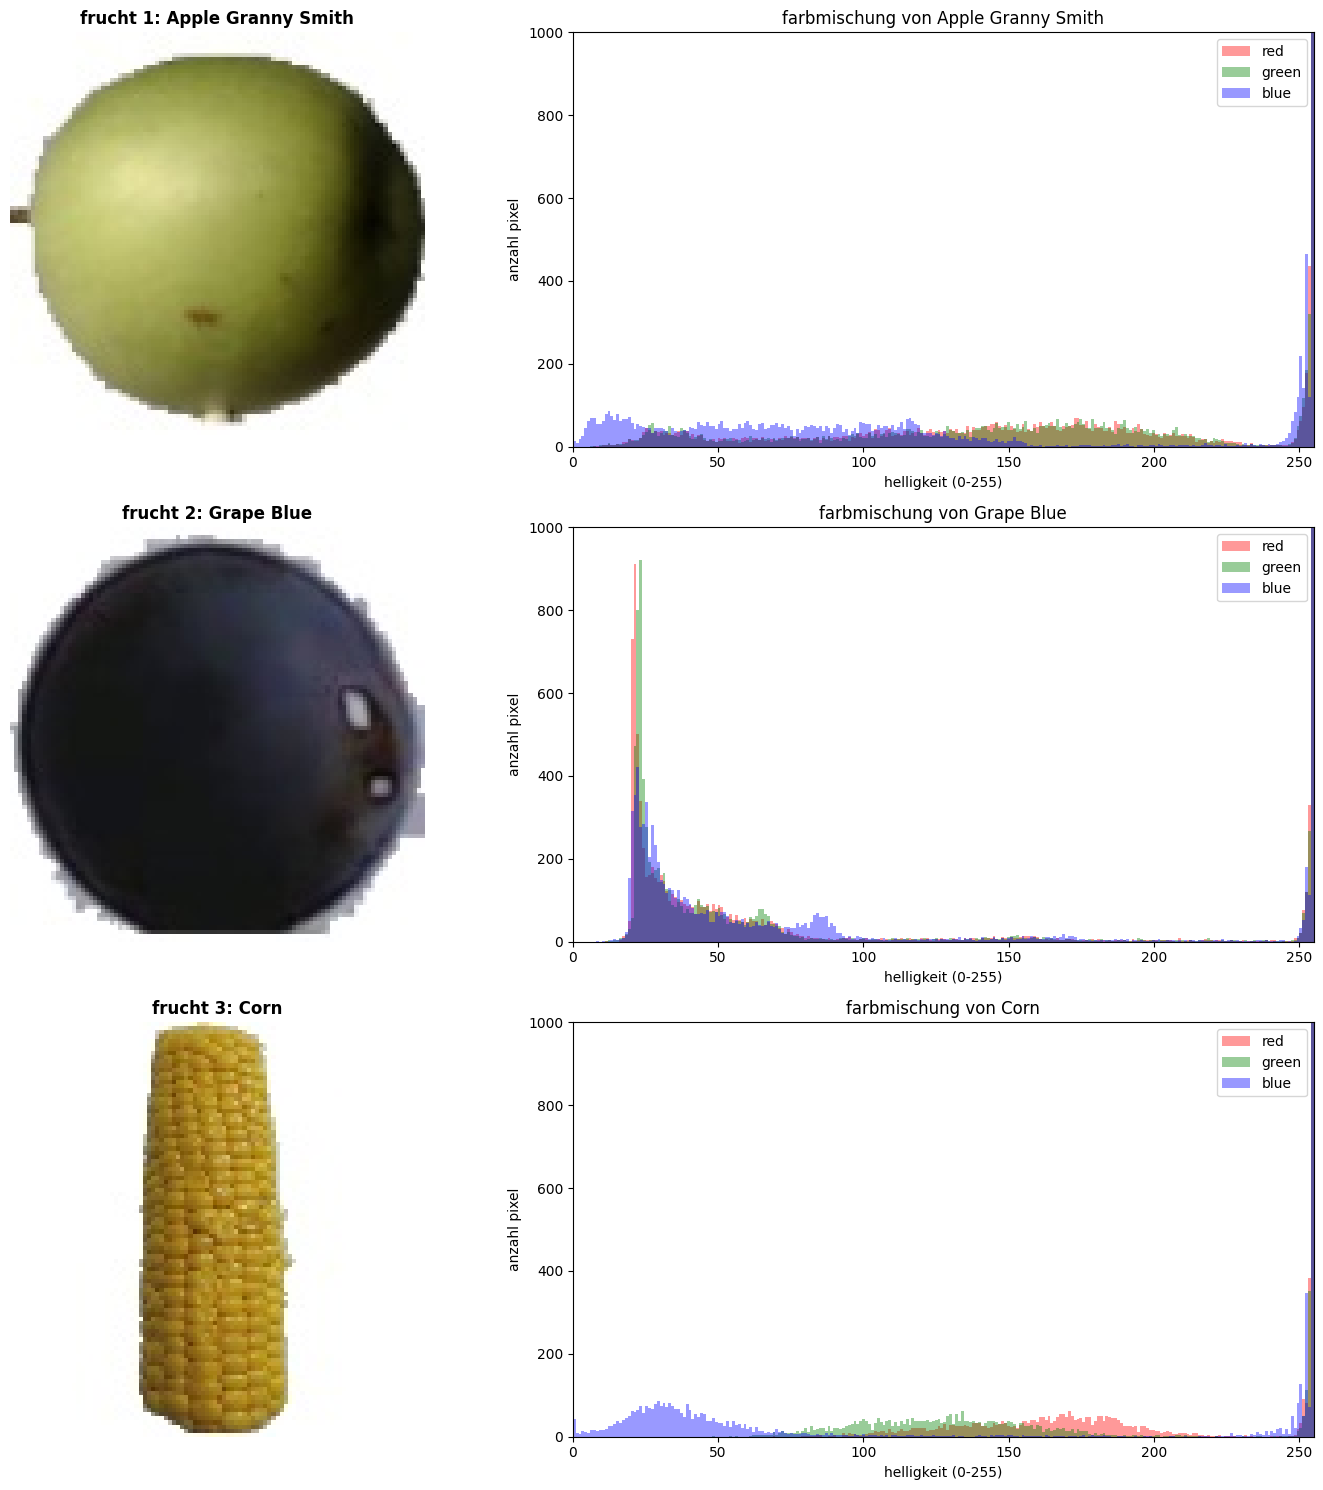

In [79]:
# 1. drei zufällige früchte aus dem validierungsset aussuchen
dataiter = iter(val_loader)
images, labels = next(dataiter)
indices = random.sample(range(len(images)), 3)

# 2. das gitter vorbereiten (3 reihen für 3 früchte)
fig, axs = plt.subplots(3, 2, figsize=(15, 15))

for i, idx in enumerate(indices):
    # bild für die anzeige vorbereiten
    img_orig = images[idx].cpu().numpy().transpose((1, 2, 0))
    img_orig = np.clip(img_orig * 0.5 + 0.5, 0, 1)
    name = CLASS_NAMES[labels[idx]]
    
    # --- linke seite: das bild ---
    axs[i, 0].imshow(img_orig)
    axs[i, 0].set_title(f"frucht {i+1}: {name}", fontweight='bold')
    axs[i, 0].axis('off')
    
    # --- rechte seite: die überlappenden farben ---
    axs[i, 1].set_title(f"farbmischung von {name}")
    axs[i, 1].set_xlim(0, 255)
    
    # hier setzen wir das limit auf 1000, wie gewünscht
    axs[i, 1].set_ylim(0, 1000)
    
    farben = ('red', 'green', 'blue')
    for j, farbe in enumerate(farben):
        # farbwerte extrahieren und auf 0-255 hochrechnen
        kanal_daten = img_orig[:, :, j].flatten() * 255
        
        # histogramm zeichnen (alpha macht es durchsichtig, damit sie überlappen)
        axs[i, 1].hist(kanal_daten, bins=256, range=(0, 255), 
                       color=farbe, alpha=0.4, label=farbe)
    
    axs[i, 1].legend(loc='upper right')
    axs[i, 1].set_xlabel("helligkeit (0-255)")
    axs[i, 1].set_ylabel("anzahl pixel")

plt.tight_layout()
plt.show()

Teste 34 externe Bilder...


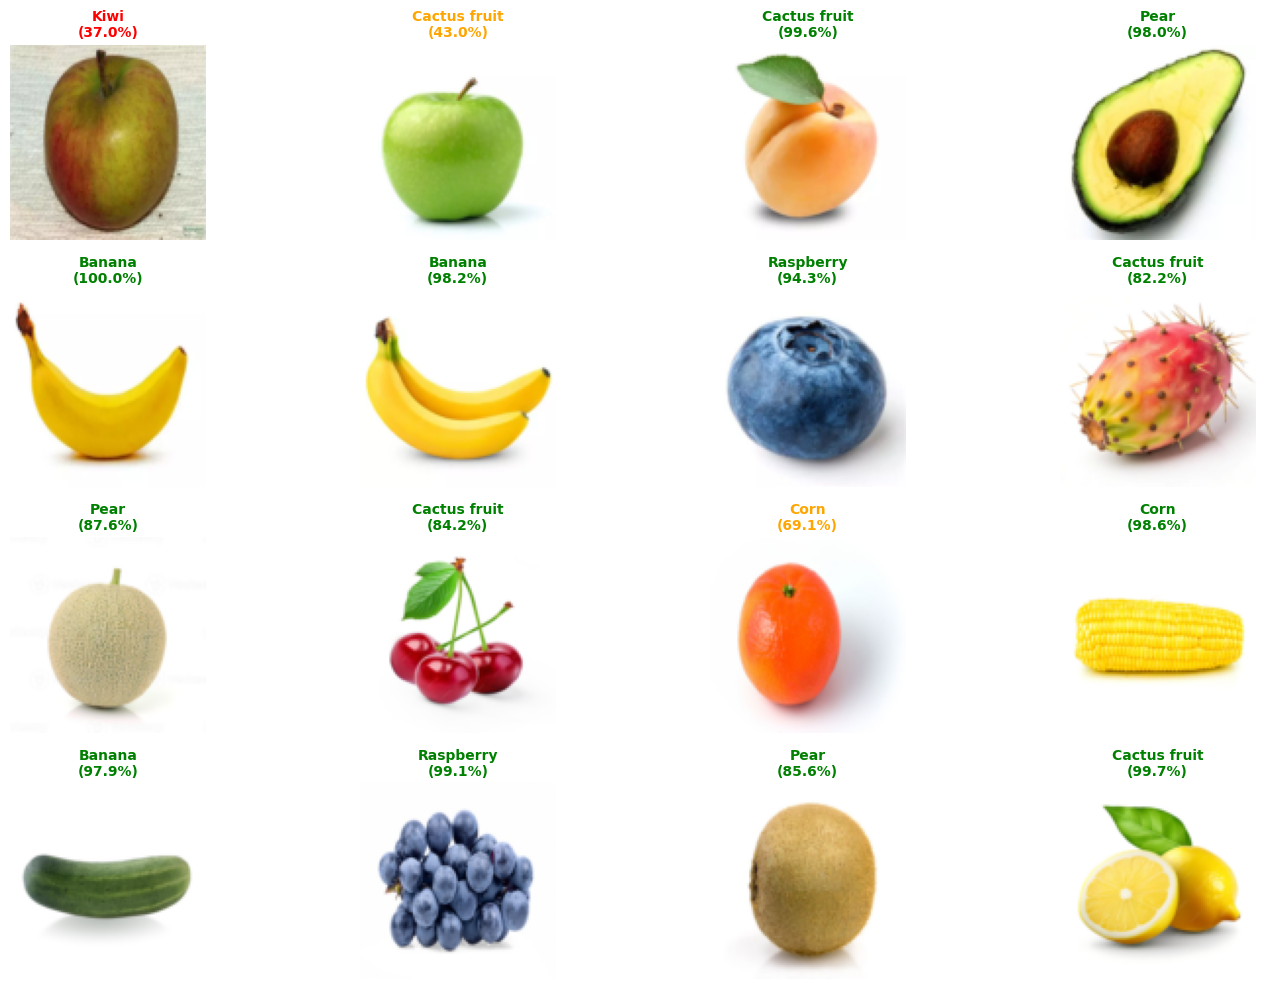

In [80]:
# Get class names from your existing dataset
class_names = CLASS_NAMES  # Use the global variable you defined earlier

# Path setup
TEST_DIR = "./downloads" 
IMG_SIZE = 100 
custom_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
])

if not os.path.exists(TEST_DIR):
    print(f"Ordner {TEST_DIR} nicht gefunden. Erstelle ihn jetzt...")
    os.makedirs(TEST_DIR, exist_ok=True)
    image_files = []
else:
    image_files = [f for f in os.listdir(TEST_DIR) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

if len(image_files) == 0:
    print(f"Keine Bilder in '{TEST_DIR}' gefunden! Lade ein Bild hoch oder prüfe den Pfad.")
else:
    print(f"Teste {len(image_files)} externe Bilder...")
    plt.figure(figsize=(15, 10))
    model.eval() 
    
    for i, img_name in enumerate(image_files[:16]): # Limit to 16 for the 4x4 grid
        try:
            img_path = os.path.join(TEST_DIR, img_name)
            image = Image.open(img_path).convert('RGB')
            
            # Send to the same device as the model
            input_tensor = custom_transform(image).unsqueeze(0).to(DEVICE)
            
            with torch.no_grad():
                outputs = model(input_tensor)
                probs = F.softmax(outputs, dim=1)
                conf, pred_idx = torch.max(probs, 1)
            
            predicted_class = class_names[pred_idx.item()]
            confidence = conf.item() * 100
            
            plt.subplot(4, 4, i+1)
            
            # Prepare image for display
            img_display = input_tensor.squeeze(0).cpu().permute(1, 2, 0).numpy()
            img_display = img_display * 0.5 + 0.5
            img_display = np.clip(img_display, 0, 1)
            
            plt.imshow(img_display)
            plt.axis('off')
            
            # Color logic based on confidence
            if confidence > 80:
                title_color = 'green'
            elif confidence >= 40:
                title_color = 'orange'
            else:
                title_color = 'red'
                
            plt.title(f"{predicted_class}\n({confidence:.1f}%)", 
                      color=title_color, fontsize=10, fontweight='bold')
                      
        except Exception as e:
            print(f"Fehler bei Bild {img_name}: {e}")
    
    plt.tight_layout()
    plt.show()